In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import pingouin
import matplotlib.pyplot as plt
import seaborn as sns
from PlanningDynamics import utils, plotting, graph
from PlanningDynamics.dataClass import nwbWrapper
from sklearn.linear_model import LinearRegression

In [2]:
fname = './data/london/london_092124.nwb'

In [3]:
data = nwbWrapper(fname, region="OFC")

loading trial data:
loading trials:


100%|██████████| 897/897 [00:02<00:00, 399.96it/s]


loading choice data:


100%|██████████| 2401/2401 [00:00<00:00, 3687.70it/s]


In [23]:
trial = 3
X, Y = np.where(data.trial_spikes[trial].neural)
eyes = data.trial_spikes[trial].eyes

trialX = data.choice_df.query("trial == @trial")
trialX.head()

plan_trial = data.fixation_df.query("active_prob < 0.2 & trial == @trial")
plan_trial.head()

trial_ts = utils.trial_ts(data.trial_spikes[trial])

In [28]:
data.trial_df.query("trial == @trial")

,start_time,stop_time,trial,trialerror,nsteps,start,target,block,blocktrialnumber,jackpot,nodes
id,,,,,,,,,,,
3,58757.0,65241.7776,3,0.0,3.0,1.0,8.0,1.0,4.0,0,"1,0,4,8"


In [24]:
trial_ts

{'t': array([0.00000000e+00, 1.00015542e+00, 2.00031085e+00, ...,
        6.43299969e+03, 6.43399984e+03, 6.43500000e+03], shape=(6435,)),
 'start': np.float64(849.9708000000028),
 'first_choice': np.float64(1034.7430000000022),
 'reward': np.float64(5798.566400000003),
 'ml_start_time': np.float64(58757.0)}

In [25]:
plan_trial

,start_time,stop_time,trial_start_time,trial_stop_time,trial,trialerror,nsteps,start,target,block,...,active_prob,step_on,step_off,node_on,node_off,fix_node,entropy_ratio,t_middle,window_size,graph_distance
id,,,,,,,,,,,,,,,,,,,,,
21,60226.0,60375.0,58757.0,65241.7776,3,0.0,3.0,1.0,8.0,1.0,...,0.0,1.0,1.0,1.0,1.0,0,0.103230,60300.5,500,2
22,60411.0,60821.0,58757.0,65241.7776,3,0.0,3.0,1.0,8.0,1.0,...,0.0,1.0,1.0,1.0,1.0,8,0.191786,60616.0,500,0
23,60843.0,61100.0,58757.0,65241.7776,3,0.0,3.0,1.0,8.0,1.0,...,0.0,1.0,1.0,1.0,1.0,4,0.159161,60971.5,500,1
24,61122.0,61365.0,58757.0,65241.7776,3,0.0,3.0,1.0,8.0,1.0,...,0.0,1.0,1.0,1.0,1.0,0,0.139134,61243.5,500,2
25,61388.0,61932.0,58757.0,65241.7776,3,0.0,3.0,1.0,8.0,1.0,...,0.0,1.0,1.0,1.0,1.0,4,0.138749,61660.0,500,1
29,64134.0,64199.0,58757.0,65241.7776,3,0.0,3.0,1.0,8.0,1.0,...,0.0,4.0,4.0,8.0,8.0,4,0.197178,64166.5,500,1
30,64210.0,64359.0,58757.0,65241.7776,3,0.0,3.0,1.0,8.0,1.0,...,0.0,4.0,4.0,8.0,8.0,4,0.135769,64284.5,500,1
31,64402.0,64587.0,58757.0,65241.7776,3,0.0,3.0,1.0,8.0,1.0,...,0.0,4.0,4.0,8.0,8.0,8,0.097340,64494.5,500,0


In [26]:
data.fixation_df.query("trial == @trial")

,start_time,stop_time,trial_start_time,trial_stop_time,trial,trialerror,nsteps,start,target,block,...,active_prob,step_on,step_off,node_on,node_off,fix_node,entropy_ratio,t_middle,window_size,graph_distance
id,,,,,,,,,,,,,,,,,,,,,
20,59800.0,60203.0,58757.0,65241.7776,3,0.0,3.0,1.0,8.0,1.0,...,0.970000,0.0,1.0,1.0,1.0,1,0.146581,60001.5,500,3
21,60226.0,60375.0,58757.0,65241.7776,3,0.0,3.0,1.0,8.0,1.0,...,0.000000,1.0,1.0,1.0,1.0,0,0.103230,60300.5,500,2
22,60411.0,60821.0,58757.0,65241.7776,3,0.0,3.0,1.0,8.0,1.0,...,0.000000,1.0,1.0,1.0,1.0,8,0.191786,60616.0,500,0
23,60843.0,61100.0,58757.0,65241.7776,3,0.0,3.0,1.0,8.0,1.0,...,0.000000,1.0,1.0,1.0,1.0,4,0.159161,60971.5,500,1
24,61122.0,61365.0,58757.0,65241.7776,3,0.0,3.0,1.0,8.0,1.0,...,0.000000,1.0,1.0,1.0,1.0,0,0.139134,61243.5,500,2
25,61388.0,61932.0,58757.0,65241.7776,3,0.0,3.0,1.0,8.0,1.0,...,0.000000,1.0,1.0,1.0,1.0,4,0.138749,61660.0,500,1
26,61955.0,62288.0,58757.0,65241.7776,3,0.0,3.0,1.0,8.0,1.0,...,0.886667,1.0,1.0,1.0,1.0,0,0.094964,62121.5,500,2
27,62310.0,63536.0,58757.0,65241.7776,3,0.0,3.0,1.0,8.0,1.0,...,1.040000,1.0,3.0,1.0,4.0,4,0.137271,62923.0,500,1
28,63559.0,64075.0,58757.0,65241.7776,3,0.0,3.0,1.0,8.0,1.0,...,1.000000,3.0,4.0,4.0,8.0,8,0.180558,63817.0,500,0


t_on : monkeylogic
fix_on/off : post-hoc analysis

In [27]:
trialX

,start_time,stop_time,trial,step,trialerror,nsteps,start,target,block,blocktrialnumber,...,node,t_on,graph_distance,spatial_distance,window_size,nodes,timeseries,use_tele,fix_on,fix_off
id,,,,,,,,,,,,,,,,,,,,,
6,59291.7430,60291.7430,3,0,0.0,3.0,1.0,8.0,1.0,4.0,...,1,59791.7430,3,3,500,"1,0,4,8","[(59291, 1000, neural pynwb.base.TimeSeries at...",False,59800,60203
7,61448.5870,62448.5870,3,1,0.0,3.0,1.0,8.0,1.0,4.0,...,0,61948.5870,2,2,500,"1,0,4,8","[(61448, 1000, neural pynwb.base.TimeSeries at...",False,61955,62288
8,62176.8943,63176.8943,3,2,0.0,3.0,1.0,8.0,1.0,4.0,...,4,62676.8943,1,1,500,"1,0,4,8","[(62176, 1000, neural pynwb.base.TimeSeries at...",False,62310,63536
9,63050.3502,64050.3502,3,3,0.0,3.0,1.0,8.0,1.0,4.0,...,8,63550.3502,0,0,500,"1,0,4,8","[(63050, 1000, neural pynwb.base.TimeSeries at...",False,63559,64075


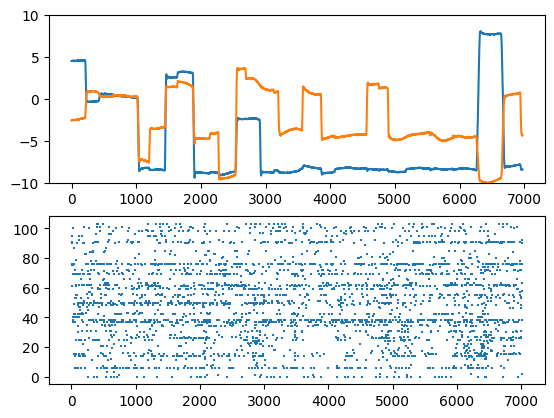

In [20]:
fig, ax = plt.subplots(2, 1)
ax[0].plot(eyes[:, 0])
ax[0].plot(eyes[:, 1])
ax[0].set_ylim([-10, 10])
ax[1].scatter(X, Y, s = 1, marker = "|")

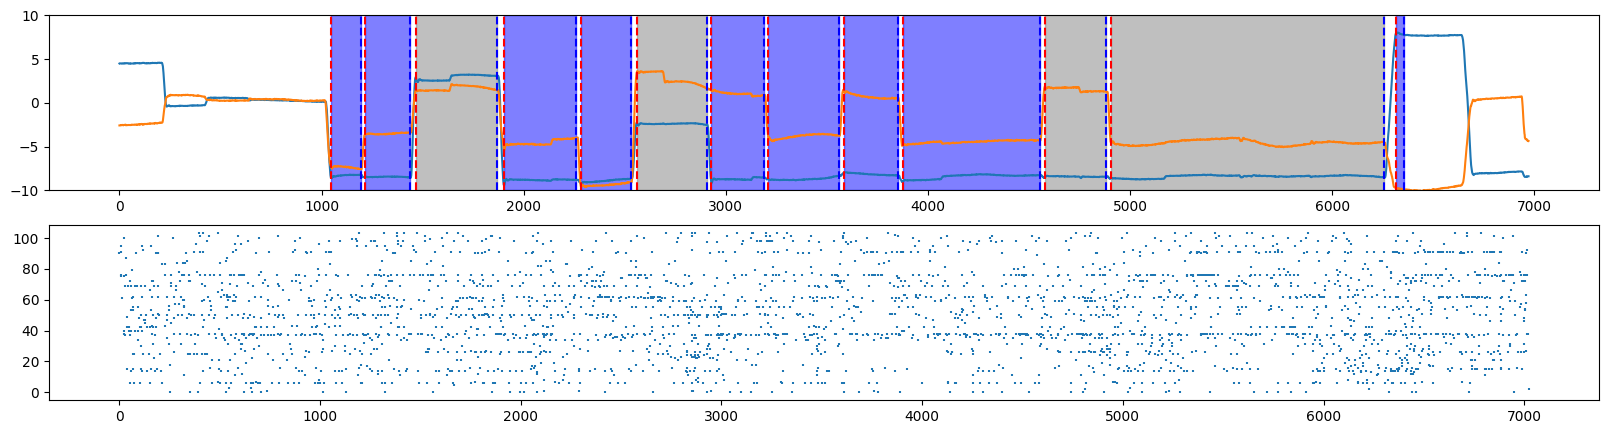

In [21]:
fig, ax = plt.subplots(2, 1, figsize=(20, 5))
ax[0].plot(eyes[:, 0])
ax[0].plot(eyes[:, 1])
ax[0].set_ylim([-10, 10])
ax[1].scatter(X, Y, s = 1, marker = "|")

for i, choice in trialX.iterrows():
    start_time = choice["fix_on"] - trial_ts["ml_start_time"]
    end_time = choice["fix_off"] - trial_ts["ml_start_time"]

    ax[0].axvline(start_time, color = "red", linestyle = "--")
    ax[0].axvline(end_time, color = "blue", linestyle = "--")
    ax[0].fill_betweenx([-10, 10], start_time, end_time, color = "gray", alpha = 0.5)
    
for i, plan in plan_trial.iterrows():
    start_time = plan["start_time"] - trial_ts["ml_start_time"]
    end_time = plan["stop_time"] - trial_ts["ml_start_time"]

    ax[0].axvline(start_time, color = "red", linestyle = "--")
    ax[0].axvline(end_time, color = "blue", linestyle = "--")
    ax[0].fill_betweenx([-10, 10], start_time, end_time, color = "blue", alpha = 0.5)

In [16]:
idx = data.choice_df.trial == 2
data.choice_spikes[idx, :, :].shape

(3, 1000, 145)

In [58]:
data.get_plan_spikes(type="mean")

100%|██████████| 943/943 [00:00<00:00, 2555.80it/s]


{'spikes': array([[0.        , 0.00613497, 0.        , ..., 0.00613497, 0.        ,
         0.        ],
        [0.00574713, 0.        , 0.00574713, ..., 0.00574713, 0.        ,
         0.        ],
        [0.        , 0.        , 0.00510204, ..., 0.00510204, 0.        ,
         0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.05      , 0.        ,
         0.        ],
        [0.        , 0.        , 0.00574713, ..., 0.02298851, 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.02116402, 0.00529101,
         0.00529101]]),
 'df':       start_time  stop_time  trial_start_time  trial_stop_time  trial  \
 id                                                                      
 5        43326.0    43489.0           42224.0     4.696151e+04      2   
 7        44062.0    44236.0           42224.0     4.696151e+04      2   
 9        44583.0    44975.0           42224.0     4.696151e+04      2   
 10       44997.0    45

In [41]:
data.fixation_df.query("active_prob <= 0.2")

,start_time,stop_time,trial_start_time,trial_stop_time,trial,trialerror,nsteps,start,target,block,...,active_prob,step_on,step_off,node_on,node_off,fix_node,entropy_ratio,t_middle,window_size,graph_distance
id,,,,,,,,,,,,,,,,,,,,,
1,36434.0,36435.0,34858.0,3.717851e+04,0,1.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,13,0.299892,36434.5,500,3
2,36464.0,36519.0,34858.0,3.717851e+04,0,1.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,14,0.091939,36491.5,500,3
4,39978.0,40118.0,38629.0,4.077246e+04,1,1.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,15,0.127171,40048.0,500,2
5,43326.0,43489.0,42224.0,4.696151e+04,2,0.0,2.0,15.0,1.0,1.0,...,0.0,0.0,0.0,15.0,15.0,1,0.107432,43407.5,500,0
7,44062.0,44236.0,42224.0,4.696151e+04,2,0.0,2.0,15.0,1.0,1.0,...,0.0,1.0,1.0,15.0,15.0,11,0.138473,44149.0,500,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6092,5896240.0,5896437.0,5888511.0,5.900439e+06,952,0.0,7.0,4.0,7.0,95.0,...,0.0,5.0,5.0,1.0,1.0,15,0.157789,5896338.5,500,2
6093,5896459.0,5896599.0,5888511.0,5.900439e+06,952,0.0,7.0,4.0,7.0,95.0,...,0.0,5.0,5.0,1.0,1.0,11,0.174265,5896529.0,500,1
6094,5896633.0,5896807.0,5888511.0,5.900439e+06,952,0.0,7.0,4.0,7.0,95.0,...,0.0,5.0,5.0,1.0,1.0,3,0.336590,5896720.0,500,1
